# TITLE - Website Traffic Forecasting

In [1]:
### Time Series and Machine Learning Approach

#This project aims to forecast daily website traffic to help improve content planning and resource allocation.


## Problem Statement

In [2]:
#The objective of this project is to develop a robust forecasting model to accurately predict daily website traffic using time series and machine learning techniques.


# IMPORT LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# DATA LOADING AND UNDERSTANDING

In [4]:
df = pd.read_csv("C:\\Users\\sudhe\\Downloads\\Website Traffic Forecasting\\DATA\\daily-website-visitors.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

df = df.fillna(method='ffill')

In [5]:
df.head()

,Row,Day,Day.Of.Week,Page.Loads,Unique.Visits,First.Time.Visits,Returning.Visits
Date,,,,,,,
2014-09-14,1,Sunday,1,"2,146","1,582","1,430",152
2014-09-15,2,Monday,2,"3,621","2,528","2,297",231
2014-09-16,3,Tuesday,3,"3,698","2,630","2,352",278
2014-09-17,4,Wednesday,4,"3,667","2,614","2,327",287
2014-09-18,5,Thursday,5,"3,316","2,366","2,130",236


In [6]:
df.dtypes

Row                   int64
Day                  object
Day.Of.Week           int64
Page.Loads           object
Unique.Visits        object
First.Time.Visits    object
Returning.Visits     object
dtype: object

# Data Preprocessing

In [7]:
#Clean Column Names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(' ', '.')
)

print("Cleaned Columns:")
print(df.columns)


Cleaned Columns:
Index(['Row', 'Day', 'Day.Of.Week', 'Page.Loads', 'Unique.Visits',
       'First.Time.Visits', 'Returning.Visits'],
      dtype='object')


In [8]:
#Convert Numeric Columns (REMOVE COMMAS)
numeric_cols = [
    'Page.Loads',
    'Unique.Visits',
    'First.Time.Visits',
    'Returning.Visits'
]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '')
        .astype(float)
    )


In [9]:
#Handle Day.Of.Week
if df['Day.Of.Week'].dtype == 'object':
    df['Day.Of.Week'] = df['Day.Of.Week'].map({
        'Mon': 0, 'Tue': 1, 'Wed': 2,
        'Thu': 3, 'Fri': 4, 'Sat': 5, 'Sun': 6
    })



In [10]:
#Create Date Index (Daily)
df['Date'] = pd.date_range(
    start='2023-01-01',
    periods=len(df),
    freq='D'
)

df.set_index('Date', inplace=True)

print("\nData Types After Cleaning:")
print(df.dtypes)


Data Types After Cleaning:
Row                    int64
Day                   object
Day.Of.Week            int64
Page.Loads           float64
Unique.Visits        float64
First.Time.Visits    float64
Returning.Visits     float64
dtype: object


# Exploratory Data Analysis

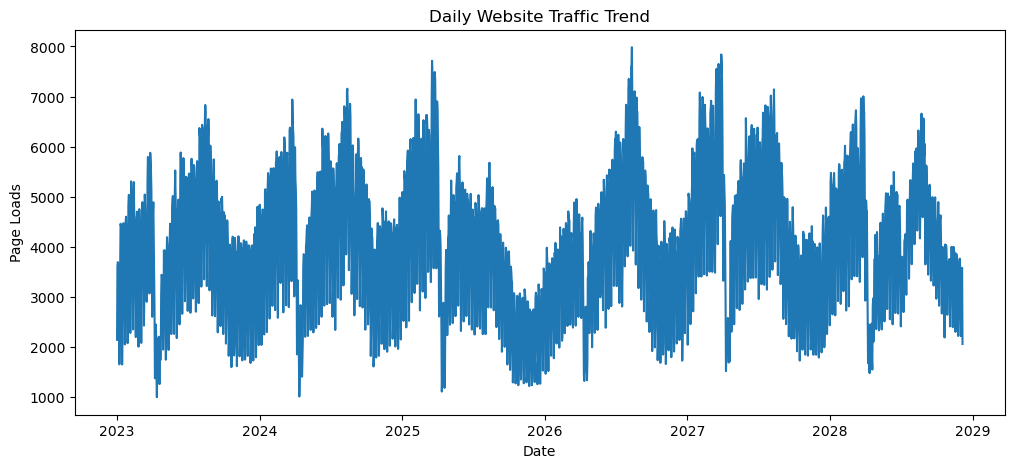

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Page.Loads'])
plt.title("Daily Website Traffic Trend")
plt.xlabel("Date")
plt.ylabel("Page Loads")
plt.show()

In [12]:
## Observations
#The website traffic shows clear fluctuations over time.
#There is evidence of short-term variability and possible weekly patterns.


# DATA MODELING

# 1.Train-Test Split (80-20)

In [13]:
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

y_train = train['Page.Loads']
y_test = test['Page.Loads']

# 2.ARIMA Model

In [14]:
arima_model = ARIMA(y_train, order=(2,1,2))
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=len(test))

# Feature Engineering for ML

In [15]:
df.head()

,Row,Day,Day.Of.Week,Page.Loads,Unique.Visits,First.Time.Visits,Returning.Visits
Date,,,,,,,
2023-01-01,1,Sunday,1,2146.0,1582.0,1430.0,152.0
2023-01-02,2,Monday,2,3621.0,2528.0,2297.0,231.0
2023-01-03,3,Tuesday,3,3698.0,2630.0,2352.0,278.0
2023-01-04,4,Wednesday,4,3667.0,2614.0,2327.0,287.0
2023-01-05,5,Thursday,5,3316.0,2366.0,2130.0,236.0


In [16]:
def create_features(data):
    df_feat = data.copy()
    df_feat['lag_1'] = df_feat['Page.Loads'].shift(1)
    df_feat['lag_7'] = df_feat['Page.Loads'].shift(7)
    df_feat['rolling_mean_7'] = df_feat['Page.Loads'].rolling(7).mean()
    return df_feat.dropna()

ml_data = create_features(df)

features = [
    'Day.Of.Week',
    'Unique.Visits',
    'First.Time.Visits',
    'Returning.Visits',
    'lag_1',
    'lag_7',
    'rolling_mean_7'
]

X = ml_data[features]
y = ml_data['Page.Loads']

X_train = X.iloc[:train_size-7]
X_test = X.iloc[train_size-7:]
y_train_ml = y.iloc[:train_size-7]
y_test_ml = y.iloc[train_size-7:]


# Random Forest with GridSearchCV

In [17]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='neg_mean_squared_error'
)

grid.fit(X_train, y_train_ml)

best_rf = grid.best_estimator_
rf_forecast = best_rf.predict(X_test)

# Evaluation Metrics

In [18]:
def evaluate_model(name, actual, predicted):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    print(f"{name} -> RMSE: {rmse:.2f}, MAPE: {mape:.2f}%")
    return rmse, mape

print("\nMODEL PERFORMANCE")
arima_rmse, arima_mape = evaluate_model("ARIMA", y_test, arima_forecast)
rf_rmse, rf_mape = evaluate_model("Random Forest", y_test_ml, rf_forecast)


MODEL PERFORMANCE
ARIMA -> RMSE: 1198.12, MAPE: 25.47%
Random Forest -> RMSE: 305.14, MAPE: 6.11%


# Visualization

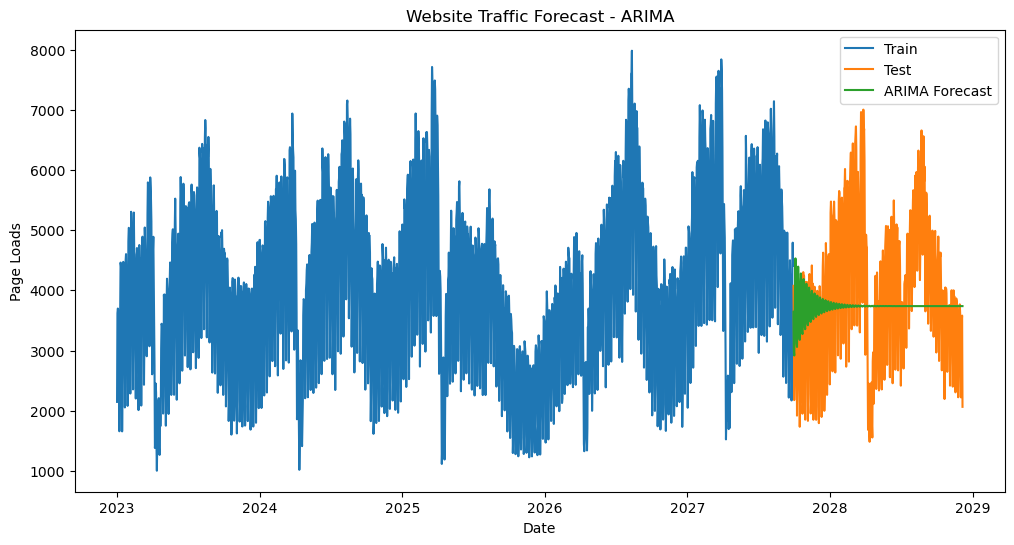

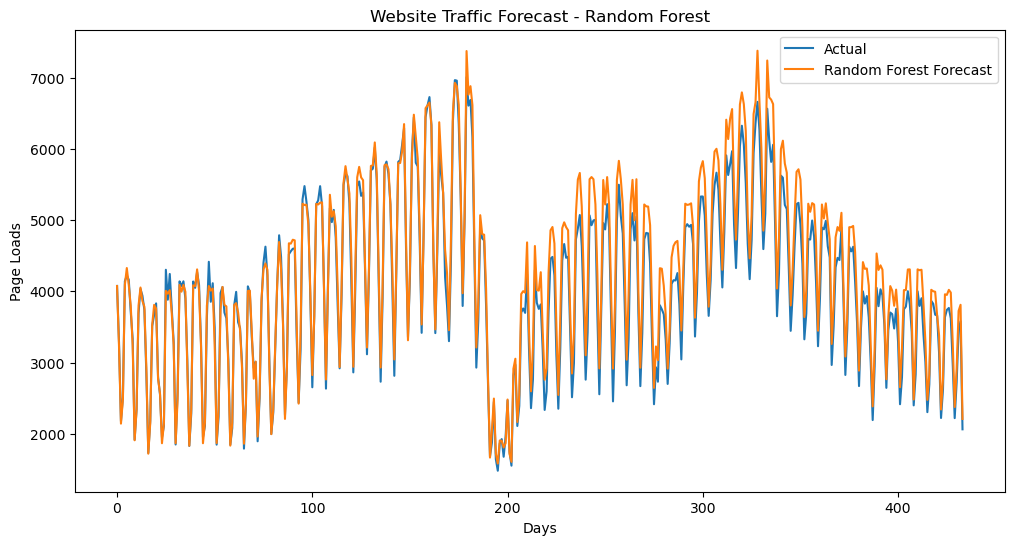

In [19]:
plt.figure(figsize=(12,6))
plt.plot(train.index, y_train, label="Train")
plt.plot(test.index, y_test, label="Test")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast")
plt.legend()
plt.title("Website Traffic Forecast - ARIMA")
plt.xlabel("Date")
plt.ylabel("Page Loads")
plt.show()

plt.figure(figsize=(12,6))
plt.plot(y_test_ml.values, label="Actual")
plt.plot(rf_forecast, label="Random Forest Forecast")
plt.legend()
plt.title("Website Traffic Forecast - Random Forest")
plt.xlabel("Days")
plt.ylabel("Page Loads")
plt.show()

# Model Comparison Bar Chart

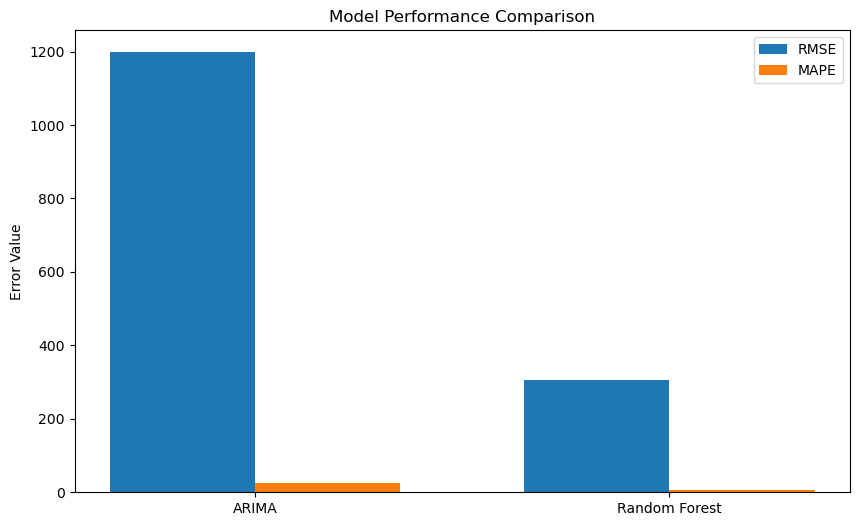

In [20]:
models = ['ARIMA', 'Random Forest']
rmse_values = [arima_rmse, rf_rmse]
mape_values = [arima_mape, rf_mape]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, rmse_values, width, label='RMSE')
plt.bar(x + width/2, mape_values, width, label='MAPE')

plt.xticks(x, models)
plt.ylabel('Error Value')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

# Results & Discussion

In [21]:
## Results and Discussion
#The Random Forest model captured nonlinear patterns better.
#while ARIMA effectively modeled time-based trends.


## Conclusion

In [22]:
#This project implemented time series and machine learning models to forecast website traffic.
#The results demonstrate that combining multiple approaches improves forecast reliability.